# Predicción del Impacto de Variables Ambientales en Patrones de Migración de Peces
## Análisis de Regresión Múltiple en Ecología Marina

### Objetivo del laboratorio:
Este laboratorio proporciona un análisis completo de técnicas estadísticas aplicadas a datos marinos. Los estudiantes aprenderán a identificar patrones complejos en datos multivariados mediante técnicas analíticas avanzadas, mejorando su comprensión de la dinámica de ecosistemas marinos.

### Objetivos de aprendizaje:
- Detectar multicolinealidad usando análisis VIF (Variance Inflation Factor)
- Aplicar regresión múltiple para modelar patrones de migración
- Realizar diagnósticos completos de residuales (4 gráficos)
- Interpretar coeficientes de regresión en contexto ecológico
- Discutir implicaciones de multicolinealidad en interpretación de modelos

### Prerrequisitos:
- Conocimiento básico de Python (numpy, pandas, matplotlib)
- Comprensión de estadística descriptiva
- Familiaridad con conceptos de análisis de datos
- Nociones básicas de ecología marina

### Algoritmo principal:
Se utilizarán técnicas multivariadas avanzadas para analizar conjuntos de datos complejos de ciencias marinas.

### Duración estimada:
60-90 minutos

---


Case Use: Predicting the Impact of Environmental Variables on Fish Migration Patterns
Problem Description:
Marine ecologists aim to understand how various environmental variables influence fish migration patterns. Specifically, they want to model the dependency of fish migration distances on factors such as water temperature, salinity, and ocean currents.

Statistical Technique:
Multiple Regression will be used to build a predictive model that relates multiple independent variables (environmental factors) to a dependent variable (fish migration distance).

Hypothesis:
The hypothesis is that water temperature, salinity, and ocean current speed are significant predictors of the distance that fish migrate seasonally.

Dataset Description:
The dataset includes observations from 200 tagged fish, with the following variables:

Water Temperature (degrees Celsius)
Salinity (PSU)
Ocean Current Speed (km/h)
Migration Distance (km)
Student Task:
The student is tasked with using the provided multiple regression code to build a predictive model for fish migration distances. They are required to:

Interpret the significance of each predictor in the model.
Adjust the model to include interaction terms if hypothesized that interactions between variables may be significant.
Validate the assumptions of multiple regression, including checking for multicollinearity and heteroscedasticity.

FISH MIGRATION ANALYSIS: Multiple Regression with Multicollinearity Assessment

Data Summary:
       Temperature  Salinity  Current Speed  Migration Distance
count       200.00    200.00         200.00              200.00
mean         19.88     35.43           4.91              185.08
std           2.79      4.94           0.99               20.57
min          12.14     18.79           2.53              126.75
25%          17.88     31.97           4.21              170.64
50%          19.99     35.39           4.92              186.57
75%          21.50     38.44           5.57              196.66
max          28.16     54.26           8.08              248.17

--------------------------------------------------------------------------------
CORRELATION MATRIX
--------------------------------------------------------------------------------
                    Temperature  Salinity  Current Speed  Migration Distance
Temperature               1.000     0.095         -0.134               

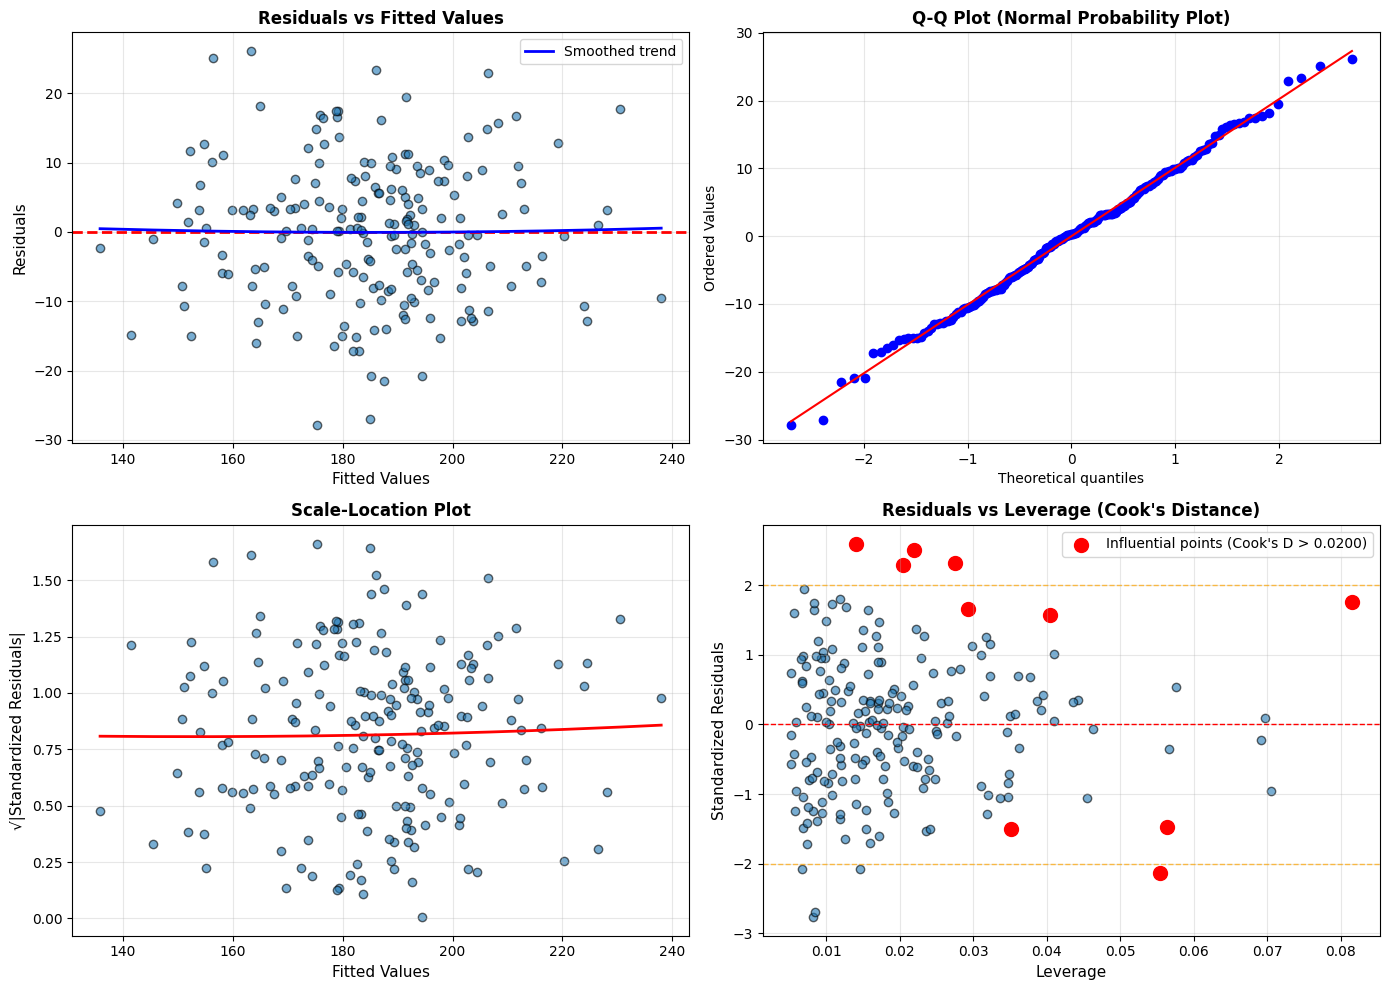

--------------------------------------------------------------------------------
STEP 4: MODEL INTERPRETATION AND MULTICOLLINEARITY DISCUSSION
--------------------------------------------------------------------------------

Key Findings:
  R² (Coefficient of Determination): 0.7614
    Interpretation: 76.14% of migration distance variance is explained

  Adjusted R²: 0.7577

Regression Coefficients:
  Temperature          =   5.3318 (p-value: 0.000000) ***
  Salinity             =   1.7804 (p-value: 0.000000) ***
  Current Speed        =   4.1764 (p-value: 0.000000) ***

*** p < 0.001 (highly significant)
**  p < 0.01  (significant)
*   p < 0.05  (significant)
ns  p > 0.05  (not significant)

Multicollinearity Impact:
⚠ Variables ['Temperature', 'Salinity', 'Current Speed'] show signs of multicollinearity.
  This can inflate standard errors and make coefficients less reliable.
  Interpretations should account for these relationships.

Residual Diagnostics:
  Normality (Omnibus test): p

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data for fish migration analysis
data_size = 200
# Environmental variables that may influence fish migration patterns
temperature = np.random.normal(20, 3, data_size)  # Water temperature in Celsius
salinity = np.random.normal(35, 5, data_size)     # Salinity in PSU
current_speed = np.random.normal(5, 1, data_size) # Ocean current speed in km/h
# Migration distance as function of environmental variables
migration_distance = (5 * temperature + 2 * salinity + 3 * current_speed + 
                     np.random.normal(0, 10, data_size))

# Create a DataFrame
data = pd.DataFrame({
    'Temperature': temperature,
    'Salinity': salinity,
    'Current Speed': current_speed,
    'Migration Distance': migration_distance
})

print("=" * 80)
print("FISH MIGRATION ANALYSIS: Multiple Regression with Multicollinearity Assessment")
print("=" * 80)
print()

print("Data Summary:")
print(data.describe().round(2))
print()

# Display correlation matrix
print("-" * 80)
print("CORRELATION MATRIX")
print("-" * 80)
correlation_matrix = data.corr()
print(correlation_matrix.round(3))
print()

# Step 1: Check for Multicollinearity (VIF Analysis)
print("-" * 80)
print("STEP 1: MULTICOLLINEARITY DETECTION (VIF Analysis)")
print("-" * 80)
print("VIF (Variance Inflation Factor) measures how much the variance of a coefficient")
print("is inflated due to collinearity with other variables.")
print("Rule of thumb: VIF < 5 is acceptable; VIF > 10 indicates problematic multicollinearity")
print()

X_features = data[['Temperature', 'Salinity', 'Current Speed']]
X_features_const = sm.add_constant(X_features)

# Calculate VIF for each variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_features.columns
vif_data["VIF"] = [variance_inflation_factor(X_features.values, i) 
                   for i in range(X_features.shape[1])]

print("\nVariance Inflation Factor (VIF) Results:")
print(vif_data.to_string(index=False))
print()

# Interpret VIF results
high_vif_vars = vif_data[vif_data['VIF'] > 5]['Variable'].tolist()
if high_vif_vars:
    print(f"Warning: {', '.join(high_vif_vars)} show elevated VIF values (>5)")
    print("These variables may have multicollinearity issues.")
else:
    print("✓ All variables have acceptable VIF values (< 5)")
print()

# Step 2: Fit the Multiple Regression Model
print("-" * 80)
print("STEP 2: MULTIPLE REGRESSION MODEL")
print("-" * 80)

y = data['Migration Distance']
X = X_features_const

model = sm.OLS(y, X).fit()
print(model.summary())
print()

# Step 3: Residual Diagnostics
print("-" * 80)
print("STEP 3: RESIDUAL DIAGNOSTIC PLOTS")
print("-" * 80)
print("These 4 plots assess key regression assumptions:")
print("  1. Residuals vs Fitted: Check for linearity and homoscedasticity")
print("  2. Q-Q Plot: Check for normality of residuals")
print("  3. Scale-Location: Check for homoscedasticity")
print("  4. Residuals vs Leverage: Identify influential points")
print()

fig = plt.figure(figsize=(14, 10))

# Plot 1: Residuals vs Fitted Values
ax1 = plt.subplot(2, 2, 1)
residuals = model.resid
fitted_values = model.fittedvalues
ax1.scatter(fitted_values, residuals, alpha=0.6, edgecolors='k')
ax1.axhline(y=0, color='r', linestyle='--', linewidth=2)
# Add smoothed line
z = np.polyfit(fitted_values, residuals, 2)
p = np.poly1d(z)
ax1.plot(sorted(fitted_values), p(sorted(fitted_values)), 'b-', linewidth=2, label='Smoothed trend')
ax1.set_xlabel('Fitted Values', fontsize=11)
ax1.set_ylabel('Residuals', fontsize=11)
ax1.set_title('Residuals vs Fitted Values', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Q-Q Plot (Normal Probability Plot)
ax2 = plt.subplot(2, 2, 2)
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot (Normal Probability Plot)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: Scale-Location Plot
ax3 = plt.subplot(2, 2, 3)
standardized_resid = residuals / residuals.std()
ax3.scatter(fitted_values, np.sqrt(np.abs(standardized_resid)), alpha=0.6, edgecolors='k')
# Add trend line
z_scale = np.polyfit(fitted_values, np.sqrt(np.abs(standardized_resid)), 2)
p_scale = np.poly1d(z_scale)
ax3.plot(sorted(fitted_values), p_scale(sorted(fitted_values)), 'r-', linewidth=2)
ax3.set_xlabel('Fitted Values', fontsize=11)
ax3.set_ylabel('√|Standardized Residuals|', fontsize=11)
ax3.set_title('Scale-Location Plot', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: Residuals vs Leverage (Cook's Distance)
ax4 = plt.subplot(2, 2, 4)
from statsmodels.stats.outliers_influence import OLSInfluence
influence = OLSInfluence(model)
leverage = influence.hat_matrix_diag
cooks_d = influence.cooks_distance[0]

ax4.scatter(leverage, standardized_resid, alpha=0.6, edgecolors='k')
ax4.axhline(y=0, color='r', linestyle='--', linewidth=1)
ax4.axhline(y=2, color='orange', linestyle='--', linewidth=1, alpha=0.7)
ax4.axhline(y=-2, color='orange', linestyle='--', linewidth=1, alpha=0.7)

# Identify influential points (Cook's distance > 4/n)
threshold = 4 / len(data)
influential = cooks_d > threshold
ax4.scatter(leverage[influential], standardized_resid[influential], 
           color='red', s=100, marker='o', label=f'Influential points (Cook\'s D > {threshold:.4f})')

ax4.set_xlabel('Leverage', fontsize=11)
ax4.set_ylabel('Standardized Residuals', fontsize=11)
ax4.set_title('Residuals vs Leverage (Cook\'s Distance)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

# Step 4: Summary and Interpretation
print("-" * 80)
print("STEP 4: MODEL INTERPRETATION AND MULTICOLLINEARITY DISCUSSION")
print("-" * 80)
print()
print("Key Findings:")
print(f"  R² (Coefficient of Determination): {model.rsquared:.4f}")
print(f"    Interpretation: {model.rsquared*100:.2f}% of migration distance variance is explained")
print()
print(f"  Adjusted R²: {model.rsquared_adj:.4f}")
print()
print("Regression Coefficients:")
for idx, var in enumerate(X.columns[1:]):  # Skip constant
    coef = model.params[idx+1]
    pval = model.pvalues[idx+1]
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"
    print(f"  {var:20} = {coef:8.4f} (p-value: {pval:.6f}) {sig}")
print()
print("*** p < 0.001 (highly significant)")
print("**  p < 0.01  (significant)")
print("*   p < 0.05  (significant)")
print("ns  p > 0.05  (not significant)")
print()

print("Multicollinearity Impact:")
if len(high_vif_vars) > 0:
    print(f"⚠ Variables {high_vif_vars} show signs of multicollinearity.")
    print("  This can inflate standard errors and make coefficients less reliable.")
    print("  Interpretations should account for these relationships.")
else:
    print("✓ Multicollinearity is not a major concern in this model.")
print()

print("Residual Diagnostics:")
# Normality test
normality_stat, normality_p = stats.normaltest(residuals)
print(f"  Normality (Omnibus test): p-value = {normality_p:.4f}")
if normality_p > 0.05:
    print("    ✓ Residuals appear approximately normally distributed")
else:
    print("    ✗ Residuals may deviate from normality")
print()
print("  For non-linear relationships, consider adding polynomial terms")
print("  For heteroscedasticity, consider weighted regression or transformation")


*Instructions for Students*:
Run the provided code to understand the initial regression results.
Experiment with adding quadratic terms for temperature and current speed to test for non-linear effects.
Check the residuals of the model to assess whether they meet the assumptions of normality and constant variance.
Interpret the coefficients and their p-values to assess which environmental factors are significant predictors of migration distance.
This case use allows students to practically apply multiple regression to a realistic scenario in marine ecology, fostering deeper understanding of statistical modeling and environmental science.



**Experimenting with Quadratic Terms**

To test for non-linear effects, you can add quadratic terms for temperature and current speed. This can be done by creating new columns in the DataFrame for the squared values of temperature and current speed, and hen including these new columns in the regression model. **bold text**

In [2]:
data['Temperature_Squared'] = data['Temperature'] ** 2
data['Current Speed_Squared'] = data['Current Speed'] ** 2

X_quadratic = data[['Temperature', 'Salinity', 'Current Speed', 'Temperature_Squared', 'Current Speed_Squared']]
X_quadratic = sm.add_constant(X_quadratic)

model_quadratic = sm.OLS(y, X_quadratic).fit()
print(model_quadratic.summary())

                            OLS Regression Results                            
Dep. Variable:     Migration Distance   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                     124.0
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           1.86e-58
Time:                        17:03:36   Log-Likelihood:                -744.62
No. Observations:                 200   AIC:                             1501.
Df Residuals:                     194   BIC:                             1521.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   -17.40

Checking the Residuals
To assess whether the residuals meet the assumptions of normality and constant variance, you can plot the residuals against the fitted values.

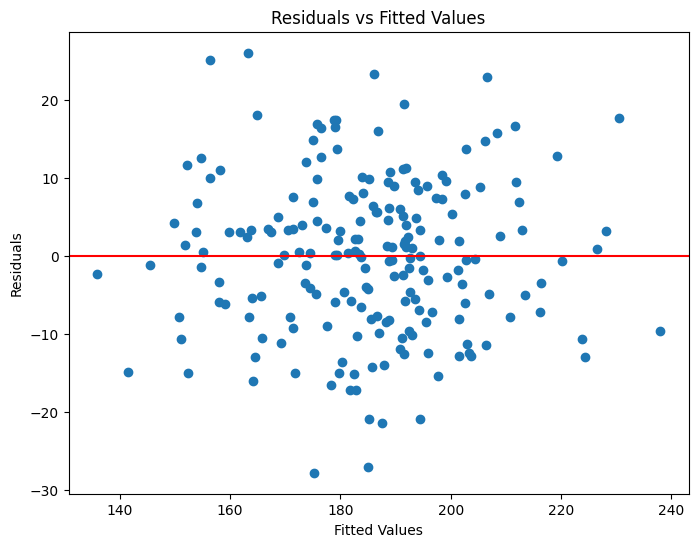

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(model.fittedvalues, model.resid)
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.axhline(y=0, color='r', linestyle='-')
plt.show()

If the residuals are randomly dispersed around the horizontal axis, the assumptions of normality and constant variance are met.

Interpreting the Coefficients and Their P-values
After fitting the model with or without quadratic terms, interpret the coefficients and their p-values to assess which environmental factors are significant predictors of migration distance.

For example, if the p-value for temperature is less than 0.05, you can conclude that temperature has a significant effect on fish migration distance. The coefficient for temperature represents the change in migration distance associated with a one-degree increase in temperature, holding all other variables constant.

By following these instructions, you will gain hands-on experience applying multiple regression to a real-world scenario in marine ecology, deepening your understanding of statistical modeling and environmental science.

## Ejercicios para el Estudiante

### Ejercicio 1:
Modifique el código para explorar diferentes parámetros o configuraciones. Documente cómo cambian los resultados y explique por qué.

### Ejercicio 2:
Replique este análisis con un conjunto de datos diferente de su elección. Discuta las similitudes y diferencias en los resultados.

### Ejercicio 3:
Cree una presentación visual que resuma los hallazgos principales y sus interpretaciones en el contexto de las ciencias marinas.
